# Homework 4

# WARNING:

**Над кодом работали совместно несколько человек, поэтому, очевидно, какие-то элементы будут совпадать.**

**За подробным расспросом: TG: [@dontknowround](https://t.me/dontknowround)**

In [10]:
from tasks import *

# Задача №1 - Лего детальки

Имеется 2 выборки из датасета фотографий лего картинок. Структура одной выборки следующая:
```
test
| -- 'target.jpg'
| -- source
|    | -- '*.jpg'
|           ...
|    | -- '*.jpg'
```
В выборке есть опорное изображение - target.jpg и набор из 20 картинок в папке source.

Ваша задача - написать программу, которая прочитает все изображения и определит на каких изображениях из папки source сфотографирована такая же лего деталька, что и деталь в target.jpg

Результатом выполнения программы должен быть файлик с названиями подходящих изображений. Пример в Datasets/gt
Снизу представлены 2 вспомогательные функции: чтение всех изображений из папки и посчет получившихся метрик точности

Результат выполнения данной задачи напрямую зависит от полученных метрик. Полученные метрики будут вычисляться из метрик по двум тестам $Accuracy=min({Accuracy}_{test1}, {Accuracy}_{test2}$)

| Accuracy | Recall | % Выполнения |
|:--------:|:------:|:------------:|
|< 0.6|< 0.4|0%|
|  >= 0.6  | >= 0.4 |     75%      |
|  >= 0.7  | >= 0.5 |     100%     |
|  >= 0.9  | >= 0.8 |     150%     |

<table><tr>
    <td> <img src="Datasets/test1/target.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="Datasets/test2/target.jpg" alt="Drawing" style="width: 400px;"/> </td>

</tr></table>

In [11]:
def GetAllImagesPaths(folder):
  folder = Path(folder)
  image_paths = [i.__str__() for i in folder.glob('*.jpg')]
  return image_paths


def GetMetrics(gt_path, prediction_path):
  with open(gt_path) as f:
    gt = set([i.strip('\n') for i in f.readlines() if len(i)])

  with open(prediction_path) as f:
    pred = set([i.strip('\n') for i in f.readlines() if len(i)])

  len_dataset = 20

  TP, TN, FP, FN = (0, ) * 4
  for i in pred:
    if i in gt:
      TP += 1
      gt.remove(i)
    else:
      FP += 1

  FN = len(gt)
  TN = len_dataset - TP - FP - FN

  accuracy = (TP + TN) / len_dataset
  recall = TP / (TP + FN)

  print(f'Acc: {accuracy:.2f}')
  print(f'Recall: {recall:.2f}')

In [12]:
images_1_path = Path(os.path.abspath('')) / 'Datasets' / 'test1' / 'source'
images_2_path = Path(os.path.abspath('')) / 'Datasets' / 'test2' / 'source'

gt_test_1 = Path(os.path.abspath('')) / 'Datasets' / 'gt' / 'test1.txt'
gt_test_2 = Path(os.path.abspath('')) / 'Datasets' / 'gt' / 'test2.txt'

pred_1 = Path(os.path.abspath('')) / 'test1.txt'
pred_2 = Path(os.path.abspath('')) / 'test2.txt'

target_1_path = Path(os.path.abspath('')) / 'Datasets' / 'test1' / 'target.jpg'
target_2_path = Path(os.path.abspath('')) / 'Datasets' / 'test2' / 'target.jpg'

In [13]:
delta = 0.15  # удалось достичь того, что работает одинаково для обеих выборок

In [14]:
image_paths = GetAllImagesPaths(images_1_path)
target = cv2.imread(target_1_path.__str__())
images = [cv2.imread(image_path) for image_path in image_paths]

l = RightImagesBoolList(target, images, delta)

with open(pred_1, "w+") as file:
  for image_path, curr_comp in zip(image_paths, l):
    if curr_comp:
      file.write(f"{os.path.basename(image_path)}\n")

In [15]:
image_paths = GetAllImagesPaths(images_2_path)
images = [cv2.imread(i) for i in image_paths]
target = cv2.imread(target_2_path.__str__())

l = RightImagesBoolList(target, images, delta)

with open(pred_2, "w+") as file:
  for image_path, curr_comp in zip(image_paths, l):
    if curr_comp:
      file.write(f"{os.path.basename(image_path)}\n")

In [16]:
GetMetrics(gt_test_1, pred_1)

Acc: 0.95
Recall: 1.00


In [17]:
GetMetrics(gt_test_2, pred_2)

Acc: 0.95
Recall: 1.00


# Задача №2 - Найти шаблон на изображении с помощью HOG и кросс-корреляции

Ваша задача - написать программу, которая сможет найти шаблон одного глаза на нескольких изображениях, в том числе затемненных. Использовать нужно HOG представление изображений, поиск шаблона сделать с помощью кросс-корреляции 

Изображение глаз человека и шаблон, который нужно на нем найти, находятся в папке hog

<table><tr>
    <td> <img src="hog/eye.png" alt="Drawing" style="width: 400px;"/> 
</tr></table>     

<table><tr>
    <td> <img src="hog/eyes.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="hog/eyes_dark.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="hog/woman.jpg" alt="Drawing" style="width: 200px;"/> </td>

</tr></table>

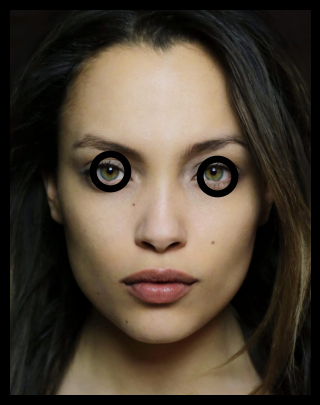

In [18]:
img = cv2.imread('hog/woman.jpg')
sample = cv2.imread('hog/eye.png')

LocateEyes(img, sample)